## Imports

In [1]:
from pathlib import Path
import numpy as np
import numpy.polynomial as nppoly
import matplotlib.pyplot as plt
import pandas as pd
import polars as pl
import seaborn as sns
import scipy.optimize as spopt
import sklearn.preprocessing as skpre
import sklearn.linear_model as sklin
import sklearn.metrics as skmet

In [2]:
plt.rcParams.update({
    "figure.autolayout": True,
})

from IPython.core import display
from IPython.core.display import HTML
HTML("<style>.container { width:100% !important; }</style>")

## Constants

In [3]:
DATA_DIR = Path("../data")
DATA_FILE = DATA_DIR / "train.csv"
ELEM_FILE = DATA_DIR / "unique_m.csv"

TARGET = "critical_temp"

## Data loading

In [4]:
data_obj = pl.read_csv(DATA_FILE, infer_schema_length=1000) # Data with general features and critical temperature
elem_obj = pl.read_csv(ELEM_FILE, infer_schema_length=1000000) # Data with chemical composition

In [5]:
selected_feature_names = [
    "wtd_std_ThermalConductivity",
    "range_atomic_radius",
    "wtd_mean_Valence",
    "wtd_entropy_atomic_mass",
    "wtd_entropy_atomic_radius",
    "number_of_elements",
    "range_fie",
    "entropy_Valence",
    "entropy_fie",
    "wtd_entropy_FusionHeat",
    "wtd_gmean_Density"
]

## Feature normalization

In [6]:
features_norm = data_obj.select(
    [
        ((pl.col(c) - pl.col(c).mean()) / pl.col(c).std()).alias(c)
        for c in selected_feature_names
    ]
)

## Linear fit

In [7]:
target_values = data_obj.select(TARGET)

model = sklin.LinearRegression()
model.fit(features_norm, target_values)

weights = model.coef_
intercept = model.intercept_

## Evaluation

In [9]:
predictions = model.predict(features_norm)

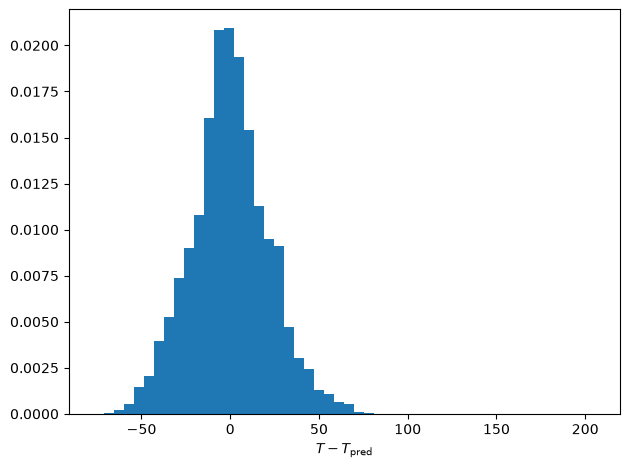

In [10]:
fig, ax = plt.subplots()

ax.hist(target_values.to_numpy() - predictions, bins=50, density=True)

ax.set_xlabel(r"$T - T_{\text{pred}}$")

plt.show()

In [11]:
print(f"R2 score: {skmet.r2_score(target_values.to_numpy(), predictions)}")

R2 score: 0.5912847042150968
